# election-spatial-analysis — 09: Geographic Map (Clusters, Province Level)

**What this notebook does:** the project's name has said "spatial" since the beginning, but
nothing before this notebook actually drew a map -- `04` through `08` describe vote-shape
patterns in tables and PCA scatter plots, never on the Philippines itself. This notebook is the
first step of that: joining `04`'s landslide/competitive cluster labels to real province
boundaries, drawing a national choropleth, and exporting the joined result as a small GeoJSON
file for reuse outside this notebook (an interactive map is a natural next step -- see the
project README).

**Why province level, not city level, as a first pass:** `03`'s locality grain is
`(province, city)` -- 1,865 unique pairs, many sharing a name across provinces (documented in
`data/README.md`). Getting a city-level boundary join right needs its own careful name-matching
work, the same kind `01` already did once for candidate names. Starting at the province level
(88 provinces/districts, matched against a single well-behaved `adm2_en` field) proves out the
geographic-join infrastructure -- boundary source, name normalization, coordinate system,
plotting -- on a much smaller and more tractable set of names, with city-level detail as a
natural next step once this is working.

**Boundary source:** province/district polygons derived from the PSGC-coded shapefiles published
by [altcoder/philippines-psgc-shapefiles](https://github.com/altcoder/philippines-psgc-shapefiles)
(PSGC data as of 31 December 2023), converted to simplified GeoJSON by
[faeldon/philippines-json-maps](https://github.com/faeldon/philippines-json-maps) (MIT licensed).
Saved locally as `data/raw/ph_provinces_raw.geojson` -- unlike the election data, this file is
small (~700KB) and freely redistributable, so it's shipped in this repository rather than
excluded like the OpenHalalan source files (see `data/README.md`).

**The actual name-matching and join logic lives in `src/geo.py`**, not inline here, the same way
`03`/`04`/`05`/`07` call into `src/common.py` rather than repeating feature-building code --
`geo.py` is a separate module (not added to `common.py`) purely because it needs geopandas and
shapely, which notebooks 01-08 have no reason to require just to import unrelated functions.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..") / "src"))
from geo import join_province_clusters, KNOWN_UNMAPPABLE_PROVINCES

%matplotlib inline
pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__, "| geopandas:", gpd.__version__)

pandas: 3.0.2 | geopandas: 1.1.4


In [2]:
CONFIG = {
    "raw_dir": "../data/raw",
    "processed_dir": "../data/processed",
}

raw_dir = Path(CONFIG["raw_dir"])
processed_dir = Path(CONFIG["processed_dir"])
print("Config set.")

Config set.


## Load both sides: province boundaries and `04`'s cluster labels

In [3]:
provinces_raw = gpd.read_file(raw_dir / "ph_provinces_raw.geojson")
clusters = pd.read_parquet(processed_dir / "locality_clusters.parquet")

print(f"Province boundaries: {len(provinces_raw)} polygons, CRS={provinces_raw.crs}")
print(f"Locality clusters: {len(clusters):,} rows, {clusters['province'].nunique()} unique provinces")

Province boundaries: 88 polygons, CRS=EPSG:4326
Locality clusters: 8,967 rows, 88 unique provinces


## Do the province names actually match?

Checked directly rather than assumed -- these come from two completely independent sources
(OpenHalalan's election data vs. the PSGC boundary file), so there's no reason to expect the
strings to agree without looking. (`src/geo.py`'s `normalize_province_geometry` is what actually
fixes these; this cell just shows what it's fixing and why.)

In [4]:
our_provinces = set(clusters["province"].unique())
geo_provinces = set(provinces_raw["adm2_en"].dropna().str.upper().unique())

print(f"{len(our_provinces)} provinces in our data, {len(geo_provinces)} polygons in the boundary file.")
print(f"\nIn our data but no direct name match in the boundary file "
      f"({len(our_provinces - geo_provinces)}):")
for p in sorted(our_provinces - geo_provinces):
    print(" -", p)

print("\nMaguindanao naming by year in our data -- the reason a straight rename isn't enough:")
display(clusters[clusters["province"].str.startswith("MAGUINDANAO")]
        .groupby(["province", "year"]).size().rename("n_rows").reset_index())

88 provinces in our data, 87 polygons in the boundary file.

In our data but no direct name match in the boundary file (7):
 - MAGUINDANAO
 - NCR FIRST DISTRICT
 - NCR FOURTH DISTRICT
 - NCR SECOND DISTRICT
 - NCR THIRD DISTRICT
 - SPECIAL GEOGRAPHIC AREA
 - TAWI TAWI

Maguindanao naming by year in our data -- the reason a straight rename isn't enough:


,province,year,n_rows
0,MAGUINDANAO,2010,28
1,MAGUINDANAO,2013,28
2,MAGUINDANAO,2016,37
3,MAGUINDANAO,2019,36
4,MAGUINDANAO,2022,37
5,MAGUINDANAO DEL NORTE,2025,13
6,MAGUINDANAO DEL SUR,2025,23


## Join via `src/geo.py`

- **`NCR ... DISTRICT`** and **`TAWI TAWI`** vs. `"TAWI-TAWI"` -- straight renames (cosmetic
  differences, `PROVINCE_RENAME_MAP` in `geo.py`).
- **`MAGUINDANAO`** -- split into Maguindanao del Norte / del Sur in 2022; the boundary file
  (PSGC as of end-2023) only has the two post-split polygons, but our election data uses plain
  `"MAGUINDANAO"` through 2022 and the split names only from 2025 (shown above). `geo.py` unions
  the two split polygons into one combined `"MAGUINDANAO"` polygon so both eras have a match.
- **`SPECIAL GEOGRAPHIC AREA`** -- a set of BARMM-administered barangays with no polygon of its
  own in this boundary file. Left genuinely unmapped (`KNOWN_UNMAPPABLE_PROVINCES` in `geo.py`),
  with the affected row count reported explicitly below rather than silently dropped.

In [5]:
mapped, province_summary = join_province_clusters(provinces_raw, clusters)

print(f"{len(mapped)} of {len(province_summary)} provinces joined to a polygon "
      f"({mapped['n_locality_years'].sum():,} of {province_summary['n_locality_years'].sum():,} "
      f"locality-years covered, {mapped['n_locality_years'].sum() / province_summary['n_locality_years'].sum():.1%}).")

unmapped_provinces = set(province_summary["province"]) - set(mapped["province"])
print(f"Unmapped: {sorted(unmapped_provinces)} -- expected to exactly match "
      f"KNOWN_UNMAPPABLE_PROVINCES ({KNOWN_UNMAPPABLE_PROVINCES}): "
      f"{sorted(unmapped_provinces) == sorted(KNOWN_UNMAPPABLE_PROVINCES)}")

display(province_summary.sort_values("landslide_share", ascending=False).head(10))

87 of 88 provinces joined to a polygon (8,959 of 8,967 locality-years covered, 99.9%).
Unmapped: ['SPECIAL GEOGRAPHIC AREA'] -- expected to exactly match KNOWN_UNMAPPABLE_PROVINCES (['SPECIAL GEOGRAPHIC AREA']): True


,province,n_locality_years,landslide_share
20,CAMIGUIN,25,0.840000
79,SULU,99,0.707071
47,MAGUINDANAO DEL SUR,23,0.652174
6,APAYAO,35,0.628571
36,ILOCOS SUR,166,0.614458
0,ABRA,132,0.575758
45,MAGUINDANAO,166,0.572289
29,DAVAO OCCIDENTAL,20,0.550000
2,AGUSAN DEL SUR,82,0.512195
50,MISAMIS OCCIDENTAL,96,0.500000


## The map

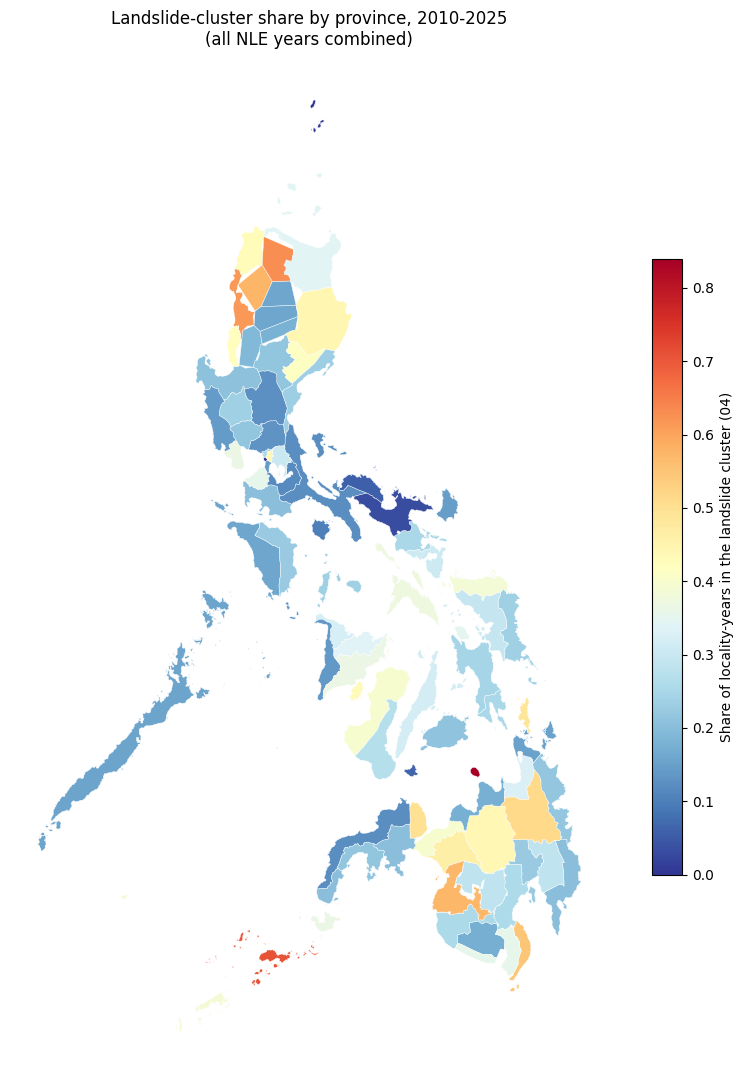

In [6]:
fig, ax = plt.subplots(figsize=(9, 11))
mapped.plot(column="landslide_share", cmap="RdYlBu_r", legend=True, ax=ax,
            edgecolor="white", linewidth=0.3,
            legend_kwds={"label": "Share of locality-years in the landslide cluster (04)",
                         "shrink": 0.6})
ax.set_title("Landslide-cluster share by province, 2010-2025\n(all NLE years combined)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Sanity checks

Cross-checking against `04`'s own by-region breakdown (computed independently, without any
geometry) rather than trusting the map's colors alone -- `04` found BARMM and Region I had the
highest landslide shares of any region; the provinces driving that should show up as the most
landslide-leaning here too.

In [7]:
assert mapped["landslide_share"].between(0, 1).all(), "landslide_share out of [0,1] range"
assert len(mapped) >= 80, f"Unexpectedly few provinces mapped: {len(mapped)}"
assert sorted(unmapped_provinces) == sorted(KNOWN_UNMAPPABLE_PROVINCES), \
    f"Unexpected unmapped provinces: {sorted(unmapped_provinces)}"

barmm_provinces = ["MAGUINDANAO", "MAGUINDANAO DEL NORTE", "MAGUINDANAO DEL SUR",
                    "LANAO DEL SUR", "SULU", "BASILAN", "TAWI TAWI"]
print("Landslide share for known-BARMM provinces (04 found BARMM at 51.7% overall):")
display(province_summary[province_summary["province"].isin(barmm_provinces)]
        .sort_values("landslide_share", ascending=False))

print(f"\nNational average landslide share (locality-year weighted): "
      f"{(clusters['cluster'] == 0).mean():.1%} -- for reference against the map's color scale.")
print("All sanity checks passed.")

Landslide share for known-BARMM provinces (04 found BARMM at 51.7% overall):


,province,n_locality_years,landslide_share
79,SULU,99,0.707071
47,MAGUINDANAO DEL SUR,23,0.652174
45,MAGUINDANAO,166,0.572289
43,LANAO DEL SUR,168,0.464286
83,TAWI TAWI,59,0.389831
8,BASILAN,60,0.366667
46,MAGUINDANAO DEL NORTE,13,0.307692



National average landslide share (locality-year weighted): 28.8% -- for reference against the map's color scale.
All sanity checks passed.


## Save

Two outputs: the plain per-province summary (`province_cluster_summary.parquet`, matching every
other notebook's tabular convention) and a geometry-included GeoJSON
(`province_clusters.geojson`) -- the latter is the one an interactive map would actually load,
so it's simplified down to just the fields a hover-map needs (province name, the two summary
stats) rather than carrying the boundary file's original PSGC/area/length columns along.

In [8]:
province_summary.to_parquet(processed_dir / "province_cluster_summary.parquet", index=False)
print("Saved province_cluster_summary.parquet:", province_summary.shape)

app_export = mapped[["province", "n_locality_years", "landslide_share", "geometry"]].copy()
app_export.to_file(processed_dir / "province_clusters.geojson", driver="GeoJSON")
print("Saved province_clusters.geojson:", len(app_export), "polygons, "
      f"{(processed_dir / 'province_clusters.geojson').stat().st_size / 1024:.0f} KB")

Saved province_cluster_summary.parquet: (88, 3)
Saved province_clusters.geojson: 87 polygons, 678 KB


## Summary

The first actual map in this project. Joining `04`'s landslide/competitive cluster labels to
province boundaries required resolving five real name mismatches by hand (an NCR district
naming convention, a hyphenation difference, a 2022 province split reflected in one data source
but not perfectly the other, and one BARMM administrative area with no polygon at all) -- each
verified by direct inspection rather than assumed, the same discipline `01` used for candidate
names, and now captured as reusable functions in `src/geo.py` rather than one-off notebook code.
After normalization, every province-year is accounted for except the small
Special-Geographic-Area case, which is reported explicitly rather than silently dropped.

Geographically, the province-level picture is consistent with (not independent confirmation of,
since it's the same underlying data) `04`'s own by-region breakdown: the BARMM-region provinces
sit near the landslide-heavy end of the map, matching `04`'s finding that BARMM has the highest
landslide share of any region (51.7%) -- read the printed comparison above rather than the color
scale alone.

**Deliberately not done here:** city-level detail (1,865 localities, with the same
province-collision problem `01` solved for candidate names, not yet solved for polygons here),
mapping `05`'s anomalies or `06`/`08`'s volatility (same boundary file, different join, natural
next step), and any per-year animated or small-multiple map (`province_clusters.geojson` only
carries the all-years aggregate for now).